In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


Auto = pd.read_csv('Auto.csv').copy()
Auto = Auto.dropna().reset_index(drop=True)

In [67]:
mpg_median = Auto['mpg'].median()
Auto['mpg01'] = (Auto['mpg'] > mpg_median).astype(int)

print("mpg median =", mpg_median)
Auto.head()

mpg median = 22.75


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,mpg01
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu,0
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320,0
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite,0
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst,0
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino,0


(b) Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other
features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.

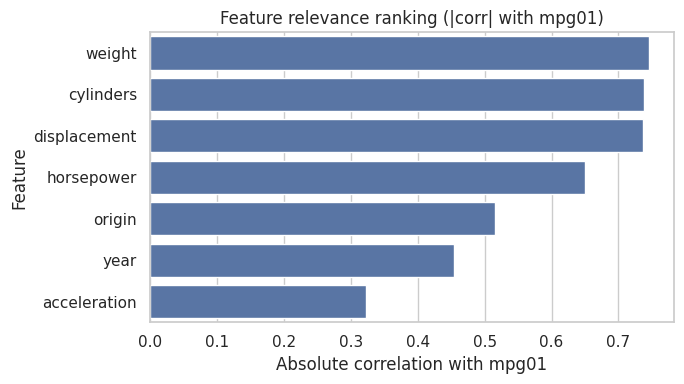

In [66]:
feat_cols = ["cylinders","displacement","horsepower","weight","acceleration","year","origin"]
corr = Auto[feat_cols + ["mpg01"]].corr(numeric_only=True)["mpg01"].drop("mpg01")
corr_abs = corr.abs().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=corr_abs.values, y=corr_abs.index, orient="h")
plt.xlabel("Absolute correlation with mpg01")
plt.ylabel("Feature")
plt.title("Feature relevance ranking (|corr| with mpg01)")
plt.tight_layout()
plt.show()

Weight, cylinders, displacement, and horsepower show strong associations with mpg01.

In [37]:
# Ensure numeric dtypes before plotting
import pandas as pd

num_cols = ["mpg","mpg01","cylinders","displacement","horsepower",
            "weight","acceleration","year","origin"]

for c in num_cols:
    if c in Auto.columns:
        Auto[c] = pd.to_numeric(Auto[c], errors="coerce")

# Drop rows that became NaN after coercion (rare but prevents plotting glitches)
Auto.dropna(subset=["horsepower","mpg01"], inplace=True)

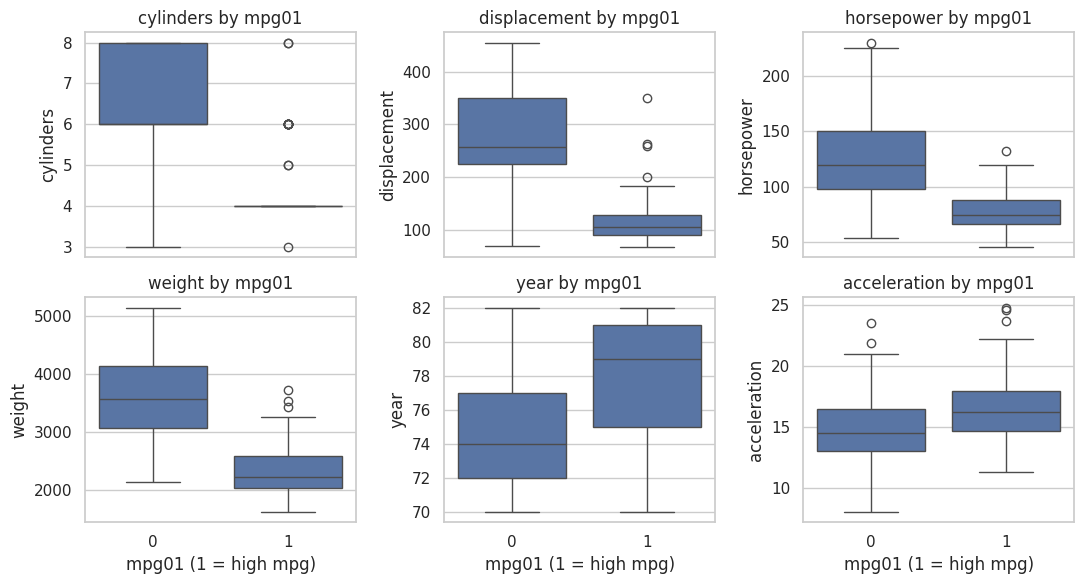

In [38]:
plot_cols = ["cylinders","displacement","horsepower","weight","year","acceleration"]

fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharex=True)
axes = axes.flatten()

for ax, c in zip(axes, plot_cols):
    sns.boxplot(x="mpg01", y=c, data=Auto, ax=ax)
    ax.set_xlabel("mpg01 (1 = high mpg)")
    ax.set_title(f"{c} by mpg01")

plt.tight_layout()
plt.show()

cylinders、displacement、horsepower、weight can effectively discriminate between fuel-efficient (mpg01 = 1) and less-efficient (mpg01 = 0) cars.

(c) Split the data into a training set and a test set.

In [42]:
from sklearn.model_selection import train_test_split

features = ['cylinders','displacement','horsepower','weight','year','acceleration']

df = Auto
X = df[features].to_numpy()
y = df['mpg01'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (274, 6) Test: (118, 6)


(d) Perform LDA on the training data in order to predict mpg01
using the variables that seemed most associated with mpg01 in
(b). What is the test error of the model obtained?

In [75]:
import numpy as np
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix
features = ['cylinders', 'displacement', 'horsepower', 'weight']

# --- LDA training & evaluation ---
lda = LinearDiscriminantAnalysis()
lda.fit(X_train[:, [features.index(f) for f in features]], y_train)
y_pred = lda.predict(X_test[:, [features.index(f) for f in features]])

acc = accuracy_score(y_test, y_pred)
test_error = 1 - acc
cm = confusion_matrix(y_test, y_pred, labels=[0,1])

print("=== (d) LDA ===")
print("Features used:", features)
print(f"Test accuracy : {acc:.3f}")
print(f"Test error    : {test_error:.3f}")
print("Confusion matrix:")

cm_df = pd.DataFrame(cm,
                     index=['Actual: 0', 'Actual: 1'],
                     columns=['Predicted: 0', 'Predicted: 1'])
display(cm_df)

=== (d) LDA ===
Features used: ['cylinders', 'displacement', 'horsepower', 'weight']
Test accuracy : 0.873
Test error    : 0.127
Confusion matrix:


,Predicted: 0,Predicted: 1
Actual: 0,51,11
Actual: 1,4,52


(e) Perform QDA on the training data in order to predict mpg01
using the variables that seemed most associated with mpg01 in
(b). What is the test error of the model obtained?

In [77]:
import numpy as np
import pandas as pd
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix
features = ['cylinders', 'displacement', 'horsepower', 'weight']

# --- QDA training & evaluation ---
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train[:, [features.index(f) for f in features]], y_train) # Select correct columns from X_train/X_test
y_pred = qda.predict(X_test[:, [features.index(f) for f in features]])

acc = accuracy_score(y_test, y_pred)
test_error = 1 - acc
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

print("=== (e) QDA ===")
print("Features used:", features)
print(f"Test accuracy : {acc:.3f}")
print(f"Test error    : {test_error:.3f}")
print("Confusion matrix:")

# Create a pandas DataFrame for better visualization with labels
cm_df = pd.DataFrame(cm,
                     index=['Actual: 0', 'Actual: 1'],
                     columns=['Predicted: 0', 'Predicted: 1'])
display(cm_df)

=== (e) QDA ===
Features used: ['cylinders', 'displacement', 'horsepower', 'weight']
Test accuracy : 0.873
Test error    : 0.127
Confusion matrix:


,Predicted: 0,Predicted: 1
Actual: 0,52,10
Actual: 1,5,51


(f) Perform logistic regression on the training data in order to pre-
dict mpg01 using the variables that seemed most associated with
mpg01 in (b). What is the test error of the model obtained?

In [79]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

features = ['cylinders', 'displacement', 'horsepower', 'weight']

logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

logit.fit(X_train[:, [features.index(f) for f in features]], y_train)
y_pred = logit.predict(X_test[:, [features.index(f) for f in features]])
acc = accuracy_score(y_test, y_pred)
test_error = 1 - acc
cm = confusion_matrix(y_test, y_pred, labels=[0,1])

print("=== (f) Logistic Regression ===")
print("Features used:", features)
print(f"Test accuracy : {acc:.3f}")
print(f"Test error    : {test_error:.3f}")
print("Confusion matrix:")

cm_df = pd.DataFrame(cm,
                     index=['Actual: 0', 'Actual: 1'],
                     columns=['Predicted: 0', 'Predicted: 1'])
display(cm_df)

=== (f) Logistic Regression ===
Features used: ['cylinders', 'displacement', 'horsepower', 'weight']
Test accuracy : 0.881
Test error    : 0.119
Confusion matrix:


,Predicted: 0,Predicted: 1
Actual: 0,52,10
Actual: 1,4,52


(g) Perform naive Bayes on the training data in order to predict
mpg01 using the variables that seemed most associated with mpg01
in (b). What is the test error of the model obtained?

In [72]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

features = ['cylinders', 'displacement', 'horsepower', 'weight']

# --- Gaussian Naive Bayes ---
nb = GaussianNB()
nb.fit(X_train[:, [features.index(f) for f in features]], y_train) # Select correct columns from X_train/X_test
y_pred = nb.predict(X_test[:, [features.index(f) for f in features]])

acc = accuracy_score(y_test, y_pred)
test_error = 1 - acc
cm = confusion_matrix(y_test, y_pred, labels=[0,1])

print("=== (g) Naive Bayes (Gaussian) ===")
print("Features used:", features)
print(f"Test accuracy : {acc:.3f}")
print(f"Test error    : {test_error:.3f}")
print("Confusion matrix:")

cm_df = pd.DataFrame(cm,
                     index=['Actual: 0', 'Actual: 1'],
                     columns=['Predicted: 0', 'Predicted: 1'])
display(cm_df)

=== (g) Naive Bayes (Gaussian) ===
Features used: ['cylinders', 'displacement', 'horsepower', 'weight']
Test accuracy : 0.881
Test error    : 0.119
Confusion matrix:


,Predicted: 0,Predicted: 1
Actual: 0,52,10
Actual: 1,4,52


(h) Perform KNN on the training data, with several values of K, in
order to predict mpg01. Use only the variables that seemed most
associated with mpg01 in (b). What test errors do you obtain?
Which value of K seems to perform the best on this data set?

=== (h) KNN test errors by K ===
 K  accuracy  test_error
 7  0.898305    0.101695
 5  0.898305    0.101695
 9  0.889831    0.110169
 3  0.881356    0.118644
13  0.881356    0.118644
11  0.881356    0.118644
15  0.881356    0.118644
17  0.881356    0.118644
25  0.881356    0.118644
21  0.881356    0.118644
 1  0.872881    0.127119

Best K = 7 with test error = 0.102 (accuracy = 0.898)


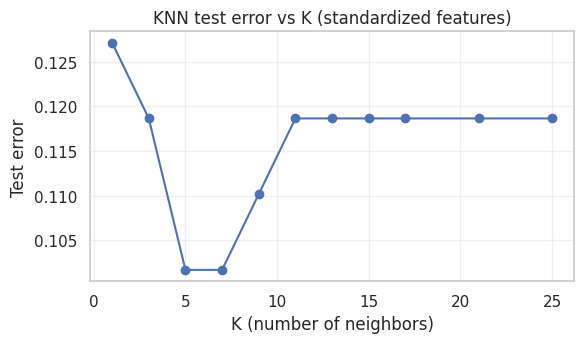


Confusion matrix for Best K:


,Predicted: 0,Predicted: 1
Actual: 0,55,7
Actual: 1,8,48


In [73]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix # Import confusion_matrix
import matplotlib.pyplot as plt

features = ['cylinders', 'displacement', 'horsepower', 'weight']

# --- K sweep ---
K_list = [1,3,5,7,9,11,13,15,17,21,25]
records = []
best_k_cm = None # To store confusion matrix for the best K

for K in K_list:
    knn = Pipeline([
        ("scaler", StandardScaler()),               # standardize features is important for distance-based KNN
        ("clf", KNeighborsClassifier(n_neighbors=K))
    ])
    knn.fit(X_train[:, [features.index(f) for f in features]], y_train) # Select correct columns from X_train/X_test
    y_pred = knn.predict(X_test[:, [features.index(f) for f in features]])
    acc = accuracy_score(y_test, y_pred)
    err = 1 - acc
    records.append((K, acc, err))
    # Find the K with the lowest error and store its confusion matrix
    if best_k_cm is None or err < (1 - accuracy_score(y_test, knn.predict(X_test[:, [features.index(f) for f in features]]))):
         best_k_cm = confusion_matrix(y_test, y_pred, labels=[0,1])


res_knn = pd.DataFrame(records, columns=["K", "accuracy", "test_error"]).sort_values("test_error")
print("=== (h) KNN test errors by K ===")
print(res_knn.to_string(index=False))

best = res_knn.iloc[0]
print(f"\nBest K = {int(best.K)} with test error = {best.test_error:.3f} (accuracy = {best.accuracy:.3f})")

# --- Optional: visualize error vs K ---
plt.figure(figsize=(6, 3.6))
plt.plot(res_knn.sort_values("K")["K"], res_knn.sort_values("K")["test_error"], marker="o")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Test error")
plt.title("KNN test error vs K (standardized features)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display confusion matrix for the best K
print("\nConfusion matrix for Best K:")
cm_df = pd.DataFrame(best_k_cm,
                     index=['Actual: 0', 'Actual: 1'],
                     columns=['Predicted: 0', 'Predicted: 1'])
display(cm_df)